In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score

# Download and load the dataset directly
url = "https://raw.githubusercontent.com/abhiii1801/AgriScan/main/soil_data.csv"

df = pd.read_csv(url)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Dataset shape: (880, 13)


,N,P,K,pH,EC,OC,S,Zn,Fe,Cu,Mn,B,Output
0,138,8.6,560,7.46,0.62,0.70,5.9,0.24,0.31,0.77,8.71,0.11,0
1,213,7.5,338,7.62,0.75,1.06,25.4,0.30,0.86,1.54,2.89,2.29,0
2,163,9.6,718,7.59,0.51,1.11,14.3,0.30,0.86,1.57,2.70,2.03,0
3,157,6.8,475,7.64,0.58,0.94,26.0,0.34,0.54,1.53,2.65,1.82,0
4,270,9.9,444,7.63,0.40,0.86,11.8,0.25,0.76,1.69,2.43,2.26,1


In [10]:
print("Dataset Shape:", df.shape)
print("Features:", df.shape[1] - 1)
print("Target: Output")
print("Missing Values:", df.isnull().sum().sum())
print("Duplicate Rows:", df.duplicated().sum())
print("Classes:", sorted(df["Output"].unique()))

Dataset Shape: (880, 13)
Features: 12
Target: Output
Missing Values: 0
Duplicate Rows: 0
Classes: [np.int64(0), np.int64(1), np.int64(2)]


In [11]:
# Separate features and target
X = df.drop(columns=["Output"])
y = df["Output"]

# Fill missing values if any
X = X.fillna(X.median())

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Target classes:", sorted(y.unique()))

X shape: (880, 12)
y shape: (880,)
Target classes: [np.int64(0), np.int64(1), np.int64(2)]


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 704
Testing samples: 176


In [13]:
depths = [1, 2, 4, 6, 10, None]

results = []

for depth in depths:

    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

    train_f1 = f1_score(
        y_train, train_pred, average="weighted"
    )

    test_f1 = f1_score(
        y_test, test_pred, average="weighted"
    )

    results.append({
        "Depth": "None" if depth is None else depth,
        "Train Acc": train_acc,
        "Test Acc": test_acc,
        "Train F1": train_f1,
        "Test F1": test_f1,
        "Gap": train_acc - test_acc
    })

results_df = pd.DataFrame(results)

display(results_df.round(3))

,Depth,Train Acc,Test Acc,Train F1,Test F1,Gap
0,1,0.874,0.875,0.853,0.854,-0.001
1,2,0.898,0.875,0.878,0.855,0.023
2,4,0.946,0.864,0.945,0.865,0.082
3,6,0.973,0.847,0.973,0.849,0.126
4,10,0.997,0.824,0.997,0.829,0.173
5,None,1.000,0.818,1.000,0.823,0.182


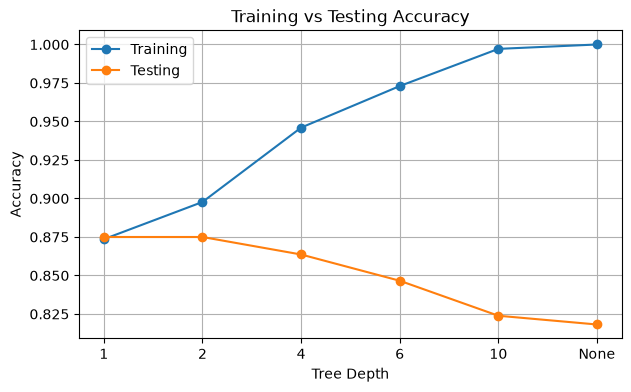

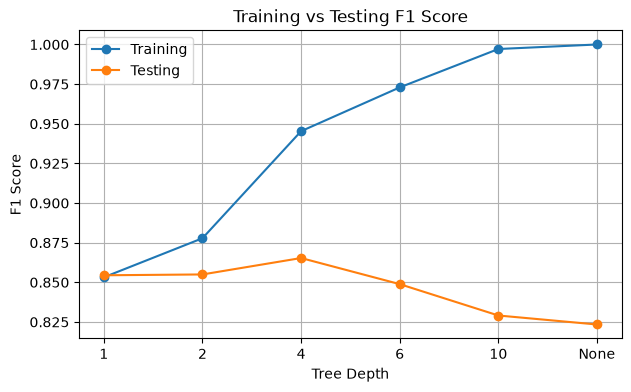

In [14]:
# Graph 1: Accuracy

plt.figure(figsize=(7, 4))

plt.plot(
    results_df["Depth"].astype(str),
    results_df["Train Acc"],
    marker="o",
    label="Training"
)

plt.plot(
    results_df["Depth"].astype(str),
    results_df["Test Acc"],
    marker="o",
    label="Testing"
)

plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")
plt.title("Training vs Testing Accuracy")
plt.legend()
plt.grid(True)
plt.show()


# Graph 2: F1 Score

plt.figure(figsize=(7, 4))

plt.plot(
    results_df["Depth"].astype(str),
    results_df["Train F1"],
    marker="o",
    label="Training"
)

plt.plot(
    results_df["Depth"].astype(str),
    results_df["Test F1"],
    marker="o",
    label="Testing"
)

plt.xlabel("Tree Depth")
plt.ylabel("F1 Score")
plt.title("Training vs Testing F1 Score")
plt.legend()
plt.grid(True)
plt.show()

In [15]:
best = results_df.loc[results_df["Test Acc"].idxmax()]

largest_gap = results_df.loc[results_df["Gap"].idxmax()]

print("===== FINAL RESULT =====")

print("Best Depth:", best["Depth"])
print("Best Test Accuracy:", round(best["Test Acc"], 3))

print("\nLargest Train-Test Gap:")
print("Depth:", largest_gap["Depth"])
print("Gap:", round(largest_gap["Gap"], 3))

print("\nConclusion:")

if largest_gap["Gap"] > 0.10:
    print("Higher complexity shows signs of overfitting.")
else:
    print("No strong overfitting based on the train-test gap.")

print("Model complexity affects generalization.")

===== FINAL RESULT =====
Best Depth: 1
Best Test Accuracy: 0.875

Largest Train-Test Gap:
Depth: None
Gap: 0.182

Conclusion:
Higher complexity shows signs of overfitting.
Model complexity affects generalization.
